# A small estimation-to-design example

This notebook uses the Rooney--Biegler biochemical oxygen demand (BOD) model as a compact introduction to `parmest` and Pyomo.DoE.

By the end, you will be able to:

* label a Pyomo model as an `Experiment`;
* estimate parameters and a local covariance matrix;
* convert covariance into prior Fisher information;
* choose the next measurement time with Pyomo.DoE; and
* **close the loop** -- take the designed measurement, re-estimate, and check that the uncertainty actually shrank.

The last step is the one that makes the design step worth doing. A design is a prediction about how much a future measurement will help; until that measurement is taken and the parameters re-estimated, the prediction is untested.

The larger reaction-kinetics tutorials use the same workflow with dynamic models and more parameters.

In [1]:
import sys

if "google.colab" in sys.modules:
    !wget -q "https://raw.githubusercontent.com/ndcbe/optimization/main/notebooks/helper.py"
    import helper
    helper.easy_install()
else:
    sys.path.insert(0, "../")
    import helper

helper.set_plotting_style()

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyomo.environ as pyo
from pyomo.contrib.doe import DesignOfExperiments, ObjectiveLib
from pyomo.contrib.parmest.experiment import Experiment
from pyomo.contrib.parmest.parmest import Estimator

## Model and observations

The response model is

$$
y(t;\theta)=\theta_1\left(1-\exp(-\theta_2t)\right),
$$

where:

* $\theta_1$ is the long-time asymptote;
* $\theta_2$ is the approach rate; and
* $t$ is the measurement time.

We assume independent measurement noise with known standard deviation $\sigma=1$. In Pyomo's experiment suffix, `measurement_error` means **standard deviation**, not variance or weight.

The legacy code column is named `time_days`; its values in this BOD example are **days**.

Time is measured in days, response and asymptote in mg/L, and rate in day$^{-1}$.
The column and Pyomo component are named `time_days` consistently.
Laky et al. (2026), Section 4.1, Equation (32), gives the same model and units;
its two-observation example is different from the six-observation fit here.


In [3]:
data = pd.DataFrame(
    {
        "time_days": [1, 2, 3, 4, 5, 7],
        "y": [8.3, 10.3, 19.0, 16.0, 15.6, 19.8],
    }
)
data

,time_days,y
0,1,8.3
1,2,10.3
2,3,19.0
3,4,16.0
4,5,15.6
5,7,19.8


## A digital experiment

At the end of this notebook we will design a new measurement and then *take* it. The Rooney--Biegler data set is historical, so there is no seventh flask to go back to. We therefore build a **digital experiment**: a known ground truth $\theta^{\text{true}}$ plus Gaussian noise, which can be queried at any time we like.

The ground truth is chosen close to the historical fit to illustrate the workflow. This choice does not validate the Gaussian noise model against the historical data.

Two data sets are now in play, and it is worth being blunt about which is which:

* `data` -- the **real** Rooney--Biegler observations. This stays the working data set for every estimate below, so the published numbers do not move.
* `simulated` -- six draws from the digital experiment at the same times. It appears once to illustrate the generator and is never used for estimation.

The digital experiment earns its keep in the final section, where it supplies the one new measurement the design step asks for.

In [4]:
# Ground truth for the digital experiment. Deliberately close to the historical
# fit; this illustrates the workflow without validating the noise assumption.
THETA_TRUE = {"asymptote": 19.0, "rate_constant": 0.53}
MEASUREMENT_STD = 1.0


def bod_response(t, theta):
    """Noise-free response y(t) = theta_1 * (1 - exp(-theta_2 * t))."""
    t = np.asarray(t, dtype=float)
    return theta["asymptote"] * (1.0 - np.exp(-theta["rate_constant"] * t))


def run_digital_experiment(t, rng):
    """Take one measurement at time t: the true response plus one noise draw."""
    return float(bod_response(t, THETA_TRUE) + rng.normal(0.0, MEASUREMENT_STD))


# A fixed seed makes every number in this notebook reproducible, including the
# new measurement taken after the design step.
calibration_rng = np.random.default_rng(60499)

simulated = pd.DataFrame(
    {
        "time_days": data["time_days"],
        "y": [run_digital_experiment(t, calibration_rng) for t in data["time_days"]],
    }
)

# Side by side: the historical measurements and six draws from the simulator.
# Compare them without treating visual similarity as model validation.
data.rename(columns={"y": "y (real)"}).assign(**{"y (digital)": simulated["y"].round(2)})

,time_days,y (real),y (digital)
0,1,8.3,7.27
1,2,10.3,14.34
2,3,19.0,15.61
3,4,16.0,15.81
4,5,15.6,19.36
5,7,19.8,18.14


## Label one experiment

Pyomo's `Experiment` abstraction uses four local suffixes:

| Suffix | Role in this example |
|---|---|
| `experiment_outputs` | measured response and observed value |
| `unknown_parameters` | parameters and nominal values |
| `measurement_error` | response standard deviation |
| `experiment_inputs` | candidate measurement time |

`parmest` uses the first three. Pyomo.DoE also needs `experiment_inputs`.

In [5]:
class BODExperiment(Experiment):
    """One biochemical oxygen demand measurement and its model labels.

    Parameters
    ----------
    data : mapping
        Measurement with keys ``time_days`` (day) and ``y`` (mg/L).
    measurement_standard_deviation : float, optional
        Known measurement standard deviation in mg/L; default 1 is illustrative.
    theta : mapping, optional
        Initial or nominal asymptote (mg/L) and rate_constant (1/day).
    design_bounds : tuple, optional
        Lower and upper allowed measurement times, in days.
    """

    def __init__(self, data, measurement_standard_deviation=1.0,
                 theta=None, design_bounds=(0, 10)):
        # Store the measurement, assumed noise, and initial parameter guesses.
        self.data = dict(data)
        self.sigma = measurement_standard_deviation
        self.theta = theta or {"asymptote": 15.0, "rate_constant": 0.5}
        self.design_bounds = design_bounds
        self.model = None

    def get_labeled_model(self):
        """Build and return the cached Pyomo model with four local suffixes."""
        if self.model is not None:
            return self.model
        # Construct the equations, then attach the reusable tool labels.
        m = build_bod_model(self.data, self.theta, self.design_bounds)
        self.model = label_bod_model(m, self.data, self.sigma)
        return self.model


In [6]:
def build_bod_model(data, theta, design_bounds):
    """Construct one response equation with physically consistent units."""
    m = pyo.ConcreteModel()
    # Unknown physical parameters; positivity is enforced by lower bounds.
    m.asymptote = pyo.Var(initialize=theta["asymptote"],
                         bounds=(1e-6, None), units=pyo.units.mg/pyo.units.L)
    m.rate_constant = pyo.Var(initialize=theta["rate_constant"],
                             bounds=(1e-6, None), units=1/pyo.units.day)
    # The input is fixed when fitting data and freed when designing a run.
    m.time_days = pyo.Var(initialize=data["time_days"],
                          bounds=design_bounds, units=pyo.units.day)
    # This variable is the prediction; the observed value is a suffix below.
    m.y = pyo.Var(initialize=data["y"], units=pyo.units.mg/pyo.units.L)
    # Estimation/design tools unfix the appropriate labeled variables.
    for v in (m.asymptote, m.rate_constant, m.time_days):
        v.fix()
    m.response = pyo.Constraint(expr=m.y == m.asymptote *
                                (1 - pyo.exp(-m.rate_constant * m.time_days)))
    return m


In [7]:
def label_bod_model(m, data, sigma):
    """Attach observations, unknowns, noise scale, and design inputs."""
    # Match each predicted output to its measured value.
    m.experiment_outputs = pyo.Suffix(direction=pyo.Suffix.LOCAL)
    m.experiment_outputs[m.y] = data["y"]
    # Tell ParmEst which parameters are shared across experiments.
    m.unknown_parameters = pyo.Suffix(direction=pyo.Suffix.LOCAL)
    for v in (m.asymptote, m.rate_constant):
        m.unknown_parameters[v] = pyo.value(v)
    # Store standard deviations, not variances, in output units (mg/L).
    m.measurement_error = pyo.Suffix(direction=pyo.Suffix.LOCAL)
    m.measurement_error[m.y] = sigma
    # Tell Pyomo.DoE which experimental input it may choose.
    m.experiment_inputs = pyo.Suffix(direction=pyo.Suffix.LOCAL)
    m.experiment_inputs[m.time_days] = data["time_days"]
    return m


## Estimate the parameters

Create one experiment per row. The weighted sum of squared errors divides each residual by its measurement standard deviation before squaring.

ParmEst's covariance interface requires more experiments than unknown parameters. With known noise variance, a full-rank information matrix can mathematically exist even when the two counts are equal; estimating noise from residuals additionally needs residual degrees of freedom.

In [8]:
def estimate_parameters(observations):
    """Fit the BOD model to a table of (time_days, y) rows.

    One `BODExperiment` is created per row. Returns the mean negative log
    likelihood, the fitted parameters, and the local covariance matrix -- everything
    needed both to report a fit and to seed the next experimental design.
    """
    experiments = [BODExperiment(row) for row in observations.to_dict("records")]
    estimator = Estimator(experiments, obj_function="SSE_weighted")

    weighted_sse, theta = estimator.theta_est()
    covariance = np.asarray(estimator.cov_est(method="finite_difference"))
    return weighted_sse, theta, covariance


weighted_sse, theta, covariance = estimate_parameters(data)

standard_deviation = np.sqrt(np.diag(covariance))
correlation = covariance / np.outer(standard_deviation, standard_deviation)

print(f"Mean half weighted SSE: {weighted_sse:.6f}")
print("Parameters:", theta)
print("Covariance:\n", covariance)
print("Correlation:\n", correlation)

assert np.isclose(theta["asymptote"], 19.1426, rtol=2e-4)
assert np.isclose(theta["rate_constant"], 0.53109, rtol=2e-4)

Mean half weighted SSE: 2.165856
Parameters: {'asymptote': 19.142575277697915, 'rate_constant': 0.5310913777423623}
Covariance:
 [[ 0.95876069 -0.06652725]
 [-0.06652725  0.00634735]]
Correlation:
 [[ 1.         -0.85280176]
 [-0.85280176  1.        ]]


In [9]:
# Archive both the measurements and the fitted curve for the handout.
fit_time = np.linspace(0, 8, 250)
results = {"time": data["time_days"].tolist(), "observed": data["y"].tolist(),
           "curve_time": fit_time.tolist(),
           "curve_y": (theta["asymptote"]*(1-np.exp(-theta["rate_constant"]*fit_time))).tolist(),
           "theta": dict(theta)}
helper.save_results("bod-fitted-response", results,
    notebook="notebooks/5-dev/BOD_Parmest_DoE.ipynb",
    source_tag="handout:l8-fit-curve", solver="Ipopt/MUMPS",
    description="Six BOD observations and the fitted nonlinear response")

[helper] wrote figures/results/bod-fitted-response.json


[helper] wrote media/figures/bod-fitted-response.png and .pdf


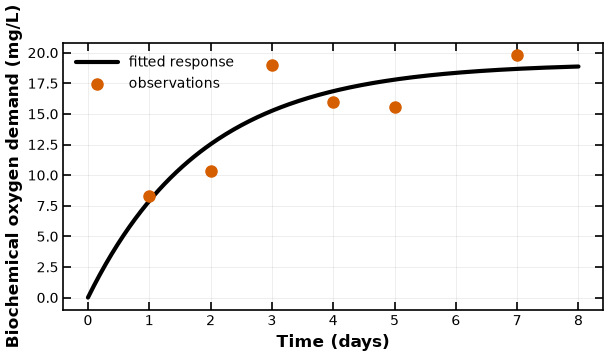

In [10]:
fig, ax = plt.subplots(figsize=(6.4, 3.5))
ax.plot(results["curve_time"], results["curve_y"], color="black", label="fitted response")
ax.scatter(results["time"], results["observed"], color="#D55E00", marker="o",
           label="observations", zorder=3)
ax.set_xlabel("Time (days)", fontsize=12)
ax.set_ylabel("Biochemical oxygen demand (mg/L)", fontsize=12)
ax.tick_params(labelsize=10)
ax.grid(alpha=0.25)
ax.legend(fontsize=10)
fig.tight_layout()
helper.save_figure(fig, "bod-fitted-response")
plt.show()

In [11]:
# MUMPS is the sparse linear solver bundled with the course Ipopt.
# This solver choice changes numerical implementation, not the likelihood.
experiments = [BODExperiment(row) for row in data.to_dict("records")]
pest = Estimator(experiments, obj_function="SSE_weighted",
                 solver_options={"linear_solver": "mumps"})
mean_nll, theta = pest.theta_est()
# ParmEst returns the average; the lecture uses the sum.
nll_hat = len(data) * mean_nll
print(f"theta = ({theta['asymptote']:.4f}, {theta['rate_constant']:.5f})")
print(f"Half weighted SSE (sum) = {nll_hat:.4f}")

theta = (19.1426, 0.53109)
Half weighted SSE (sum) = 12.9951


In [12]:
# Use expected information (Gauss-Newton) for the design demonstration.
cov_fd = pest.cov_est(method="finite_difference")
covariance = np.asarray(cov_fd)
# Other interfaces (see the validation note below before using them):
# cov_rh = pest.cov_est(method="reduced_hessian")
# cov_ad = pest.cov_est(method="automatic_differentiation_kaug")
print("Verified Gauss-Newton covariance (finite differences):")
print(cov_fd.round(5).to_string())

Verified Gauss-Newton covariance (finite differences):
               asymptote  rate_constant
asymptote        0.95876       -0.06653
rate_constant   -0.06653        0.00635


### Check the covariance implementation

For this nonlinear model the inverse **observed** Hessian need not equal inverse **expected** information. The analytic calculation below validates the selected finite-difference method.

In the installed course build, `cov_est(method="reduced_hessian")` returned a matrix differing from the independently differentiated observed Hessian. Its call is shown above for API reference, but it is **not** used in this design demonstration. The third interface also requires a working `k_aug` installation. These software options are not interchangeable mathematical definitions.

In [13]:
# Independent checks of the mathematics and objective normalization.
t = data["time_days"].to_numpy(float)
a, k = theta["asymptote"], theta["rate_constant"]
e = np.exp(-k*t)
Q = np.column_stack([1-e, a*t*e])
r = data["y"].to_numpy(float) - a*(1-e)
M = Q.T @ Q  # sigma = 1
H = M.copy()
H[0, 1] -= np.sum(r*t*e)
H[1, 0] = H[0, 1]
H[1, 1] += np.sum(r*a*t*t*e)
assert np.allclose(cov_fd, np.linalg.inv(M), rtol=2e-5, atol=1e-7)
assert np.isclose(nll_hat, 0.5*(r@r), rtol=1e-10)
assert np.linalg.norm(Q.T @ r) < 1e-5
print("Independent inverse observed Hessian:")
print(np.linalg.inv(H))
from pyomo.util.check_units import assert_units_consistent
assert_units_consistent(experiments[0].get_labeled_model())


Independent inverse observed Hessian:
[[ 0.97048544 -0.06764595]
 [-0.06764595  0.00645409]]


In [14]:
import contextlib
import io
import logging

# Try all interfaces. Keep diagnostics available without flooding the handout.
covariance_methods = {"finite_difference": np.asarray(cov_fd)}
covariance_diagnostics = {}
for method in ("reduced_hessian", "automatic_differentiation_kaug"):
    diagnostic = io.StringIO()
    logging_level = logging.root.manager.disable
    try:
        logging.disable(logging.CRITICAL)
        with contextlib.redirect_stdout(diagnostic), contextlib.redirect_stderr(diagnostic):
            value = np.asarray(pest.cov_est(method=method), dtype=float)
        covariance_methods[method] = value
        print(method + ":")
        print(np.round(value, 6))
        print("Matches analytic inverse information:",
              np.allclose(value, np.linalg.inv(M), rtol=2e-4, atol=1e-6))
    except Exception as error:
        print(method + ": unavailable in this run (" + type(error).__name__ + ")")
        print(str(error).split("\n")[0][:180])
    finally:
        logging.disable(logging_level)
        covariance_diagnostics[method] = diagnostic.getvalue()
print("Analytic inverse observed Hessian (different target):")
print(np.round(np.linalg.inv(H), 6))


reduced_hessian:
[[ 0.947415 -0.065445]
 [-0.065445  0.006244]]
Matches analytic inverse information: False


automatic_differentiation_kaug:
[[ 0.958759 -0.066527]
 [-0.066527  0.006347]]
Matches analytic inverse information: True
Analytic inverse observed Hessian (different target):
[[ 0.970485 -0.067646]
 [-0.067646  0.006454]]


## Why a chi-squared cutoff?

If $Z_1,\ldots,Z_k$ are independent standard normal variables, their squared length
$S=\sum_jZ_j^2$ has the chi-squared distribution $\chi_k^2$.
It is nonnegative, has mean $k$ and variance $2k$, and its shape depends on the
number of independent components (degrees of freedom).
The 95th percentile leaves a 5% upper tail. See Held & Sabanés Bové,
*Applied Statistical Inference*, Appendix A.5, p. 337.

For correlated parameter errors, rotate to covariance eigenvectors and divide by
the corresponding standard deviations. Under the multivariate normal approximation,
these components are independent standard normals. Their squared length is
$(\theta-\hat\theta)^T V^{-1}(\theta-\hat\theta)$, giving the Wald ellipse.
For a likelihood-ratio test, evaluate the nonlinear negative log likelihood directly:
$D=2[\ell(\theta_0)-\ell(\hat\theta)]$. Reject when $D>\chi^2_{k,0.95}$.
A joint test fixes both BOD parameters ($k=2$); a profile test fixes one and refits the
other ($k=1$). Both calibrations are asymptotic.

In [15]:
from scipy.stats import chi2

# Deterministic probability densities: no random simulation or fitting is needed.
chi_x = np.linspace(0.02, 12, 800)
results = {"x": chi_x.tolist(), "df": [1, 2, 5],
           "density": {str(k): chi2.pdf(chi_x, k).tolist() for k in (1, 2, 5)},
           "cutoffs": {str(k): float(chi2.ppf(0.95, k)) for k in (1, 2, 5)}}
assert np.isclose(results["cutoffs"]["2"], 5.991464547107979)
helper.save_results("bod-chi-squared", results,
    notebook="notebooks/5-dev/BOD_Parmest_DoE.ipynb",
    source_tag="handout:l8-chi-squared", solver="scipy.stats.chi2 (no solver)",
    description="Chi-squared densities and 95% quantiles")

[helper] wrote figures/results/bod-chi-squared.json


[helper] wrote media/figures/bod-chi-squared.png and .pdf


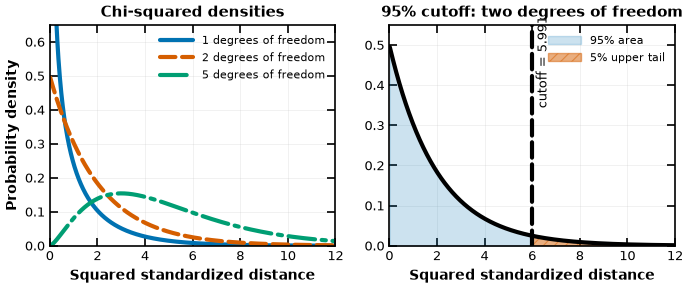

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(7.2, 3.2))
x = np.asarray(results["x"])
for k, color, style in zip(results["df"], ["#0072B2", "#D55E00", "#009E73"], ["-", "--", "-."]):
    axes[0].plot(x, results["density"][str(k)], color=color, linestyle=style,
                 label=f"{k} degrees of freedom")
axes[0].set(xlim=(0, 12), ylim=(0, 0.65), xlabel="Squared standardized distance", ylabel="Probability density")
axes[0].legend(fontsize=8)
axes[0].set_title("Chi-squared densities")
y = np.asarray(results["density"]["2"])
c = results["cutoffs"]["2"]
axes[1].plot(x, y, color="black")
axes[1].fill_between(x, y, where=x<=c, color="#0072B2", alpha=0.2, label="95% area")
axes[1].fill_between(x, y, where=x>=c, color="#D55E00", alpha=0.5, hatch="///", label="5% upper tail")
axes[1].axvline(c, color="black", linestyle="--")
axes[1].text(c+0.15, 0.35, f"cutoff = {c:.3f}", fontsize=9, rotation=90)
axes[1].set(xlim=(0, 12), ylim=(0, 0.55), xlabel="Squared standardized distance", title="95% cutoff: two degrees of freedom")
axes[1].legend(fontsize=8, loc="upper right")
for ax in axes:
    ax.set_xlabel("Squared standardized distance", fontsize=10)
    ax.set_ylabel(ax.get_ylabel(), fontsize=10)
    ax.set_title(ax.get_title(), fontsize=11)
    ax.tick_params(labelsize=9)
    ax.grid(alpha=0.2)
fig.tight_layout()
helper.save_figure(fig, "bod-chi-squared")
plt.show()

## Bootstrap: simulate or resample, then refit

A **bootstrap** approximates the sampling distribution by repeatedly refitting artificial data sets.
For the fixed BOD times and assumed known Gaussian noise, use the **parametric bootstrap** below.
A residual bootstrap instead resamples centered residuals at fixed times; a case bootstrap resamples whole (time, response) experiments. These answer different sampling questions.

The 200 replicates are a classroom demonstration, not a precision claim about interval endpoints. Bootstrap intervals are approximate and can be unreliable with six observations. The assumed standard deviation 1 is illustrative; the historical residuals are larger than this noise assumption predicts.

Regression resampling reference: Wehrens, Putter & Buydens (2000), §7.2, pp. 47–48, [DOI](https://doi.org/10.1016/S0169-7439(00)00102-7).

Use fixed-design parametric resampling when the planned times and assumed error law
represent the repeated experiment. Case resampling instead redraws complete
(time, response) pairs; some times disappear and others repeat. It is appropriate
for sampling cases from a population, and need not represent a fixed experimental
design. See Wehrens, Putter, and Buydens (2000), Section 7.2, pp. 47–48.
The bootstrap cloud estimates sampling variation; it is not itself a calibrated
joint confidence region or a Bayesian posterior.


In [17]:
# Parametric bootstrap: keep times fixed; simulate noise and refit.
rng = np.random.default_rng(804)
bootstrap_theta = []
for b in range(200):
    sample = data.copy()
    sample["y"] = bod_response(data["time_days"], theta) + rng.normal(0, 1, len(data))
    exps = [BODExperiment(row) for row in sample.to_dict("records")]
    fit = Estimator(exps, obj_function="SSE_weighted",
                    solver_options={"linear_solver": "mumps"})
    _, theta_b = fit.theta_est()
    bootstrap_theta.append(dict(theta_b))
bootstrap_theta = pd.DataFrame(bootstrap_theta)
print("Illustrative 95% percentile intervals (200 replicates):")
print(bootstrap_theta.quantile([0.025, 0.975]).round(4).to_string())

Illustrative 95% percentile intervals (200 replicates):
       asymptote  rate_constant
0.025     17.663         0.3958
0.975     21.479         0.6916


### Built-in case bootstrap

`theta_est_bootstrap` resamples Experiment objects. It does **not** implement the fixed-time parametric algorithm above. ParmEst also filters insufficiently diverse resamples; with six observations this distinction matters.

In [18]:
# Resample whole (time, response) experiments; retain sample indices.
case_theta = pest.theta_est_bootstrap(100, seed=804, return_samples=True)
# Extreme values flag fits to inspect, not intervals to trust.
print("Case fits with rate > 10:", int((case_theta["rate_constant"] > 10).sum()))

Case fits with rate > 10: 8


Some case resamples produce extremely large rate estimates. The response becomes nearly saturated at all selected times. This can reflect weak information **or a solver stopping at a poor stationary point**. Independent checks found lower objective values for several returned fits. A solver reporting convergence does not make a fit reliable. Inspect the fit and try other initial values before constructing intervals; do not silently delete these samples. The fixed-design parametric bootstrap above is a different sampling experiment.

In [19]:
# Diagnose case fits without deleting or replacing samples.
# At fixed rate the least-squares asymptote has a closed-form solution.
poor_fits = 0
for _, fit in case_theta.iterrows():
    sample = data.iloc[fit["samples"]]
    ts, ys = sample["time_days"].to_numpy(), sample["y"].to_numpy()
    returned_sse = np.sum((ys - fit["asymptote"] *
                          (1-np.exp(-fit["rate_constant"]*ts)))**2)
    best_trial = returned_sse
    for trial_rate in (0.1, 0.2, 0.3, 0.5, 0.75, 1.0, 2.0):
        basis = 1-np.exp(-trial_rate*ts)
        trial_asymptote = (basis @ ys)/(basis @ basis)
        best_trial = min(best_trial, np.sum((ys-trial_asymptote*basis)**2))
    poor_fits += best_trial < returned_sse - 1e-3
print("Case fits with a demonstrably better feasible point:", poor_fits)


Case fits with a demonstrably better feasible point: 2


## Profile likelihood: fix one parameter, refit the others

For each trial value c, minimize the **summed** negative log likelihood with one parameter fixed. Plot twice its increase above the unrestricted minimum. A pointwise 95% interval uses the chi-squared cutoff with **one** degree of freedom (3.841), under the usual likelihood-ratio regularity and large-sample assumptions.

The model below uses the same response, data, unit noise and positive parameter domain as the Experiment model. The profile uses stable Pyomo calls; the draft API is shown separately.

Reference: [Raue et al. (2009)](https://doi.org/10.1093/bioinformatics/btp358), Eq. (10).

In [20]:
def profile_model(observations):
    """BOD negative log likelihood, with shared parameters."""
    m = pyo.ConcreteModel()
    m.asymptote = pyo.Var(initialize=theta["asymptote"], bounds=(1e-6, None))
    m.rate_constant = pyo.Var(initialize=theta["rate_constant"], bounds=(1e-6, None))
    m.nll = pyo.Objective(expr=0.5 * sum(
        (row.y - m.asymptote * (1 - pyo.exp(-m.rate_constant * row.time_days)))**2
        for row in observations.itertuples()))
    return m


def profile_parameter(name, grid):
    """Fix one parameter and re-optimize the other at each grid point."""
    m = profile_model(data)
    solver = pyo.SolverFactory("ipopt")
    solver.options["linear_solver"] = "mumps"
    rows = []
    for value in grid:
        getattr(m, name).fix(float(value))
        pyo.assert_optimal_termination(solver.solve(m))
        rows.append((float(value), 2 * (pyo.value(m.nll) - nll_hat)))
    return np.asarray(rows)


profile_grids = {"asymptote": np.linspace(17, 22, 101),
                 "rate_constant": np.linspace(0.35, 0.8, 101)}
profiles = {name: profile_parameter(name, grid)
            for name, grid in profile_grids.items()}

### Proposed ParmEst API (not executed)

[Pyomo PR #3875](https://github.com/Pyomo/pyomo/pull/3875) is open and draft as checked September 16, 2026; inspected head `a8967c8d28ebf315fc3674383407754c796e9af1`. This preview requires that development branch and its dependencies. It is deliberately disabled in the released course environment.

**Normalization matters:** this PR computes `2 * (obj - obj_hat)`, while this Estimator minimizes an average over experiments. Multiply that statistic by the number of experiments to compare to the summed-likelihood cutoff. The figure below is from the explicit stable-Pyomo implementation, not a run of the draft API.

In [21]:
# DRAFT API: Pyomo PR #3875, head a8967c8 (not in the course release).
# Syntax preview only; results below use the stable Pyomo loop above.
RUN_DRAFT_API = False
if RUN_DRAFT_API:
    draft_profiles = pest.profile_likelihood(
        profiled_theta=["asymptote", "rate_constant"],
        grid=profile_grids, theta_hat=dict(theta),
        obj_hat=mean_nll, warmstart="neighbor")
    # PR uses 2 * delta(average objective). Convert to our summed NLL.
    draft_profiles["profiles"]["lr_stat"] *= len(data)

In [22]:
from scipy.stats import chi2
cutoff = chi2.ppf(0.95, df=1)
for name, curve in profiles.items():
    # Interpolate the two threshold crossings; fail if the grid misses either.
    k = np.argmin(curve[:, 1])
    assert curve[0, 1] > cutoff and curve[-1, 1] > cutoff
    left = np.interp(cutoff, curve[:k+1, 1][::-1], curve[:k+1, 0][::-1])
    right = np.interp(cutoff, curve[k:, 1], curve[k:, 0])
    print(f"{name}: profile 95% interval [{left:.4f}, {right:.4f}]")
    assert curve[k, 1] >= -1e-5
print(f"Likelihood-ratio cutoff (1 parameter): {cutoff:.4f}")

asymptote: profile 95% interval [17.4284, 21.4132]
rate_constant: profile 95% interval [0.3915, 0.7133]
Likelihood-ratio cutoff (1 parameter): 3.8415


In [23]:
results = {"bootstrap": bootstrap_theta.to_dict("list"),
           "profiles": {k: v.tolist() for k, v in profiles.items()},
           "cutoff": float(cutoff), "theta": dict(theta),
           "covariance": np.asarray(cov_fd).tolist()}
helper.save_results("bod-uncertainty", results,
    notebook="notebooks/5-dev/BOD_Parmest_DoE.ipynb",
    source_tag="handout:l8-profile-model", solver="Ipopt/MUMPS",
    description="BOD parametric bootstrap and explicit Pyomo likelihood profiles")

[helper] wrote figures/results/bod-uncertainty.json


[helper] wrote media/figures/bod-uncertainty.png and .pdf


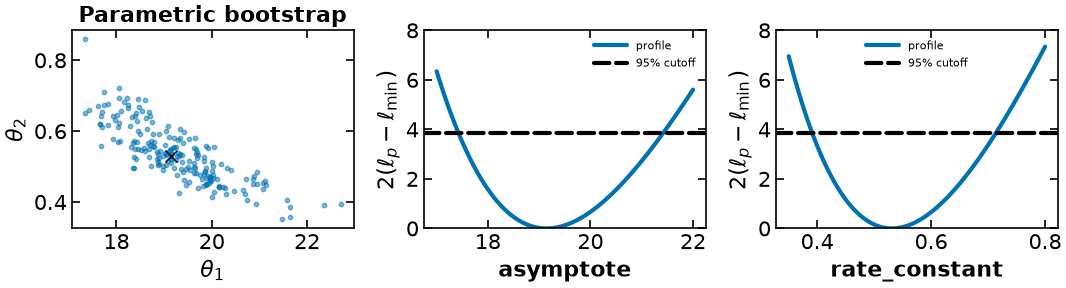

In [24]:
def plot_bod_uncertainty(results):
    """Compare a bootstrap cloud and likelihood profiles."""
    fig, axes = plt.subplots(1, 3, figsize=(11, 3.2))
    boot = results["bootstrap"]
    axes[0].scatter(boot["asymptote"], boot["rate_constant"],
                    s=10, alpha=0.5, color="#0072B2", marker="o")
    axes[0].plot(results["theta"]["asymptote"], results["theta"]["rate_constant"],
                 "kx", ms=8)
    axes[0].set(xlabel=r"$\theta_1$", ylabel=r"$\theta_2$", title="Parametric bootstrap")
    for ax, (name, values) in zip(axes[1:], results["profiles"].items()):
        curve = np.asarray(values)
        ax.plot(curve[:, 0], curve[:, 1], color="#0072B2", label="profile")
        ax.axhline(results["cutoff"], color="black", ls="--", label="95% cutoff")
        ax.set(xlabel=name, ylabel=r"$2(\ell_{p}-\ell_{\min})$", ylim=(0, 8))
        ax.legend(fontsize=8)
    fig.tight_layout()
    return fig


fig = plot_bod_uncertainty(results)
helper.save_figure(fig, "bod-uncertainty")

In [25]:
profile_results = results  # Preserve the one-parameter profile archive.
from scipy.stats import chi2
# Joint likelihood region: evaluate the nonlinear objective on a 2D grid.
asymptote_grid = np.linspace(15.5, 23.5, 241)
rate_grid = np.linspace(0.25, 0.95, 241)
AA, KK = np.meshgrid(asymptote_grid, rate_grid)
predicted = AA[..., None] * (1 - np.exp(-KK[..., None] * data["time_days"].to_numpy()))
joint_lr = np.sum((data["y"].to_numpy() - predicted)**2, axis=-1) - 2*nll_hat
joint_cutoff = float(chi2.ppf(0.95, 2))
# Boundary must be contained in the grid, rather than silently clipped.
assert min(joint_lr[0].min(), joint_lr[-1].min(),
           joint_lr[:, 0].min(), joint_lr[:, -1].min()) > joint_cutoff
region_results = {"asymptote_grid": asymptote_grid.tolist(),
                  "rate_grid": rate_grid.tolist(), "joint_lr": joint_lr.tolist(),
                  "cutoff": joint_cutoff, "theta": dict(theta),
                  "covariance": covariance.tolist(),
                  "bootstrap": bootstrap_theta.to_dict("list")}
for name in ("bod-confidence-regions", "bod-bootstrap-regions"):
    helper.save_results(name, region_results,
        notebook="notebooks/5-dev/BOD_Parmest_DoE.ipynb",
        source_tag="handout:l8-regions-data", solver="Ipopt/MUMPS + direct likelihood evaluation",
        description="Joint nonlinear likelihood region and GN ellipse for the same BOD fit")

results = region_results


[helper] wrote figures/results/bod-confidence-regions.json
[helper] wrote figures/results/bod-bootstrap-regions.json


[helper] wrote media/figures/bod-confidence-regions.png and .pdf


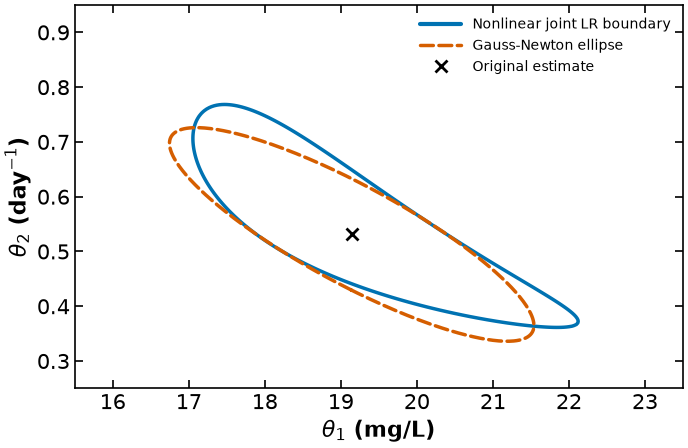

In [26]:
def plot_region_comparison(results):
    """Compare nonlinear likelihood and local Gaussian regions."""
    fig, ax = plt.subplots(figsize=(7.2, 4.8))
    center = np.array([results["theta"]["asymptote"], results["theta"]["rate_constant"]])
    values, vectors = np.linalg.eigh(np.asarray(results["covariance"]))
    angle = np.linspace(0, 2*np.pi, 361)
    ellipse = center[:, None] + vectors @ (np.sqrt(results["cutoff"]*values)[:, None]
               * np.vstack([np.cos(angle), np.sin(angle)]))
    ax.contour(results["asymptote_grid"], results["rate_grid"], results["joint_lr"],
               levels=[results["cutoff"]], colors=["#0072B2"], linewidths=2.5)
    ax.plot([], [], color="#0072B2", ls="-", label="Nonlinear joint LR boundary")
    ax.plot(*ellipse, color="#D55E00", ls="--", lw=2.5, label="Gauss-Newton ellipse")
    ax.plot(*center, "kx", ms=9, mew=2, label="Original estimate")
    ax.set(xlabel=r"$\theta_1$ (mg/L)", ylabel=r"$\theta_2$ (day$^{-1}$)")
    ax.legend(fontsize=10, loc="upper right")
    fig.tight_layout()
    return fig

fig = plot_region_comparison(results)
helper.save_figure(fig, "bod-confidence-regions")


[helper] wrote media/figures/bod-bootstrap-regions.png and .pdf


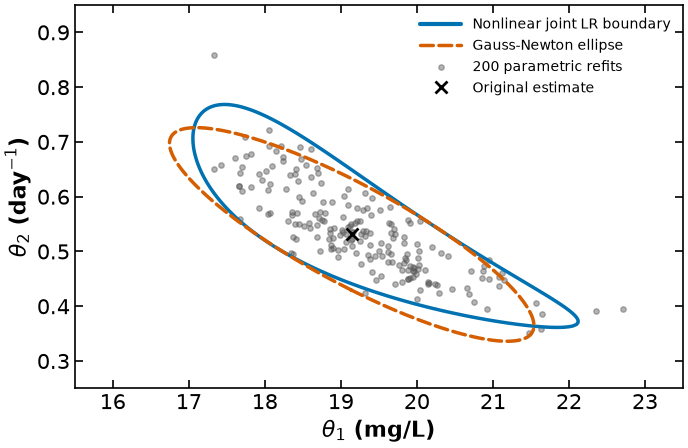

In [27]:
def plot_region_comparison(results):
    """Compare nonlinear likelihood and local Gaussian regions."""
    fig, ax = plt.subplots(figsize=(7.2, 4.8))
    center = np.array([results["theta"]["asymptote"], results["theta"]["rate_constant"]])
    values, vectors = np.linalg.eigh(np.asarray(results["covariance"]))
    angle = np.linspace(0, 2*np.pi, 361)
    ellipse = center[:, None] + vectors @ (np.sqrt(results["cutoff"]*values)[:, None]
               * np.vstack([np.cos(angle), np.sin(angle)]))
    ax.contour(results["asymptote_grid"], results["rate_grid"], results["joint_lr"],
               levels=[results["cutoff"]], colors=["#0072B2"], linewidths=2.5)
    ax.plot([], [], color="#0072B2", ls="-", label="Nonlinear joint LR boundary")
    ax.plot(*ellipse, color="#D55E00", ls="--", lw=2.5, label="Gauss-Newton ellipse")
    ax.scatter(results["bootstrap"]["asymptote"], results["bootstrap"]["rate_constant"],
               s=15, alpha=0.45, color="0.35", marker="o", label="200 parametric refits")
    ax.plot(*center, "kx", ms=9, mew=2, label="Original estimate")
    ax.set(xlabel=r"$\theta_1$ (mg/L)", ylabel=r"$\theta_2$ (day$^{-1}$)")
    ax.legend(fontsize=10, loc="upper right")
    fig.tight_layout()
    return fig

fig = plot_region_comparison(results)
helper.save_figure(fig, "bod-bootstrap-regions")


In [28]:
results = profile_results
helper.save_results("bod-profile-results", results,
    notebook="notebooks/5-dev/BOD_Parmest_DoE.ipynb",
    source_tag="handout:l8-profile-model", solver="Ipopt/MUMPS",
    description="One-parameter profile likelihood results")


[helper] wrote figures/results/bod-profile-results.json


[helper] wrote media/figures/bod-profile-results.png and .pdf


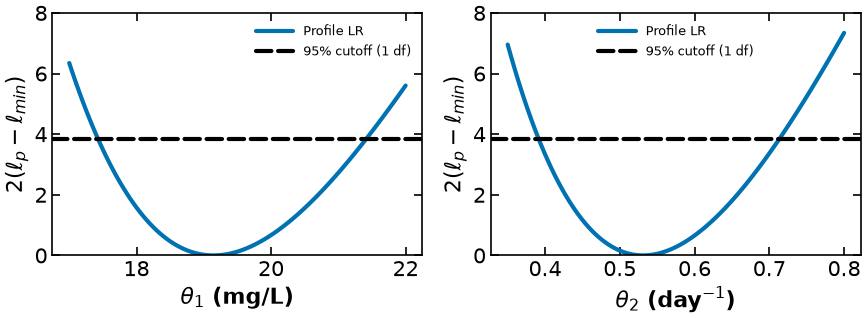

In [29]:
def plot_profiles(results):
    """Display each one-parameter likelihood profile at its own cutoff."""
    fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
    labels = [r"$\theta_1$ (mg/L)", r"$\theta_2$ (day$^{-1}$)"]
    for ax, (name, values), label in zip(axes, results["profiles"].items(), labels):
        curve = np.asarray(values)
        ax.plot(curve[:, 0], curve[:, 1], color="#0072B2", ls="-", label="Profile LR")
        ax.axhline(results["cutoff"], color="black", ls="--", label="95% cutoff (1 df)")
        ax.set(xlabel=label, ylabel=r"$2(\ell_p-\ell_{min})$", ylim=(0, 8))
        ax.legend(fontsize=9)
    fig.tight_layout()
    return fig

fig = plot_profiles(results)
helper.save_figure(fig, "bod-profile-results")


## From covariance to experimental design

The design uses the finite-difference Gauss-Newton covariance, independently checked against analytic BOD sensitivities. Its inverse approximates the expected Fisher information at the fitted parameter:

$$\mathbf{F}_{\mathrm{prior}}=\mathbf{V}_{\theta}^{-1}.$$

For one new measurement with standard deviation 1,

$$
\mathbf{F}_{\mathrm{new}}(t)=\mathbf{F}_{\mathrm{prior}}+
\mathbf{q}(t)\mathbf{q}(t)^\mathsf{T},
$$

with sensitivity vector

$$
\mathbf{q}(t)=
\begin{bmatrix}
1-\exp(-\theta_2t)\\
\theta_1t\exp(-\theta_2t)
\end{bmatrix}.
$$

The two sensitivity components favor different time regions. A useful design balances the new direction against information already contained in the prior.

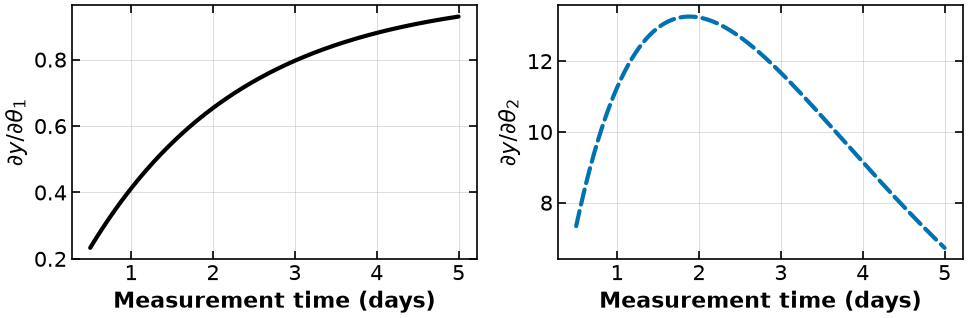

In [30]:
t_design = np.linspace(0.5, 5, 300)
q_asymptote = 1 - np.exp(-theta["rate_constant"] * t_design)
q_rate = theta["asymptote"] * t_design * np.exp(-theta["rate_constant"] * t_design)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].plot(t_design, q_asymptote, color="black")
axes[0].set_ylabel(r"$\partial y/\partial\theta_1$")
axes[1].plot(t_design, q_rate, color="#0072B2", linestyle="--")
axes[1].set_ylabel(r"$\partial y/\partial\theta_2$")
for ax in axes:
    ax.set_xlabel("Measurement time (days)")
    ax.grid(True)
plt.tight_layout()
plt.show()

## Optimize the next measurement

Pyomo 6.10 configures the objective and solver behavior in the `DesignOfExperiments` constructor. `run_doe()` performs the optimization and stores the summary in `doe.results`.

The bounds in `BODExperiment` restrict the new measurement to 0.5--5 days.

In [31]:
prior_fim = np.linalg.inv(covariance)
design_experiment = BODExperiment(
    {"time_days": 2.0, "y": 10.0},
    measurement_standard_deviation=1.0,
    theta=dict(theta),
    design_bounds=(0.5, 5.0),
)

# Use the MUMPS linear solver available in the course environment.
ipopt = pyo.SolverFactory("ipopt")
ipopt.options["linear_solver"] = "mumps"

doe = DesignOfExperiments(
    experiment=design_experiment,
    fd_formula="central",
    step=1e-3,
    objective_option=ObjectiveLib.determinant,
    prior_FIM=prior_fim,
    improve_cholesky_roundoff_error=True,
    solver=ipopt,
    tee=False,
)
doe.run_doe(model=doe.create_doe_model())

optimal_time = doe.results["Experiment Design"][0]
print(f"D-optimal next measurement: {optimal_time:.6f} days")

D-optimal next measurement: 1.499740 days


## Verify with an independent calculation

For this two-parameter model, a dense grid is cheap. It provides an independent check on the software formulation and local optimizer.

Dense-grid optimum: 1.499000 days
Prior log determinant:   6.401107
Updated log determinant: 6.742537


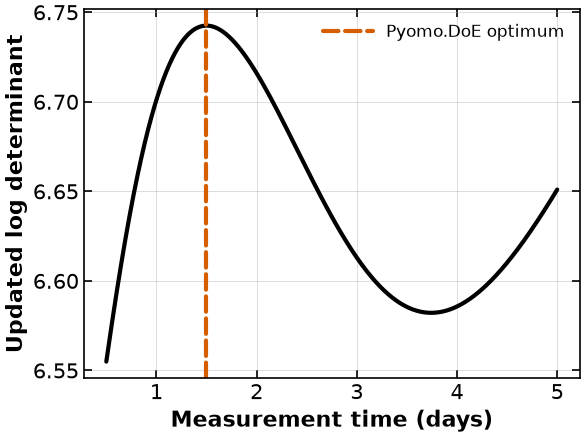

In [32]:
def updated_fim(t):
    sensitivity = np.array(
        [
            1 - np.exp(-theta["rate_constant"] * t),
            theta["asymptote"] * t * np.exp(-theta["rate_constant"] * t),
        ]
    )
    return prior_fim + np.outer(sensitivity, sensitivity)


grid = np.linspace(0.5, 5, 2001)
grid_logdet = np.array([np.linalg.slogdet(updated_fim(t))[1] for t in grid])
grid_time = grid[np.argmax(grid_logdet)]

print(f"Dense-grid optimum: {grid_time:.6f} days")
print(f"Prior log determinant:   {np.linalg.slogdet(prior_fim)[1]:.6f}")
print(f"Updated log determinant: {grid_logdet.max():.6f}")
assert abs(optimal_time - grid_time) < 0.02

plt.plot(grid, grid_logdet, color="black")
plt.axvline(optimal_time, color="#D55E00", linestyle="--", label="Pyomo.DoE optimum")
plt.xlabel("Measurement time (days)")
plt.ylabel("Updated log determinant")
plt.grid(True)
plt.legend()
plt.show()

In [33]:
# Evaluate all five criteria on the same time grid and parameter scaling.
criteria_time = np.linspace(0.5, 5, 901)
criteria_information = np.asarray([updated_fim(t) for t in criteria_time])
eigenvalues = np.linalg.eigvalsh(criteria_information)
assert np.all(eigenvalues > 0)
criteria_values = {
    "A: minimize trace inverse": np.sum(1/eigenvalues, axis=1),
    "D: maximize determinant": np.prod(eigenvalues, axis=1),
    "E: maximize smallest eigenvalue": eigenvalues[:, 0],
    "ME: minimize condition number": eigenvalues[:, 1]/eigenvalues[:, 0],
    "Pseudo-A: maximize trace": np.sum(eigenvalues, axis=1),
}
criteria_results = {"time": criteria_time.tolist(),
    "criteria": {key: value.tolist() for key, value in criteria_values.items()}}
helper.save_results("bod-design-criteria", criteria_results,
    notebook="notebooks/5-dev/BOD_Parmest_DoE.ipynb",
    source_tag="handout:l8-criteria-data", solver="analytic sensitivity grid",
    description="All five BOD design criteria at common nominal parameters and units")
for label, values in criteria_values.items():
    index = np.argmin(values) if "minimize" in label else np.argmax(values)
    print(f"{label}: grid optimum at {criteria_time[index]:.3f} days")

results = criteria_results


[helper] wrote figures/results/bod-design-criteria.json
A: minimize trace inverse: grid optimum at 5.000 days
D: maximize determinant: grid optimum at 1.500 days
E: maximize smallest eigenvalue: grid optimum at 5.000 days
ME: minimize condition number: grid optimum at 5.000 days
Pseudo-A: maximize trace: grid optimum at 1.885 days


[helper] wrote media/figures/bod-design-criteria.png and .pdf


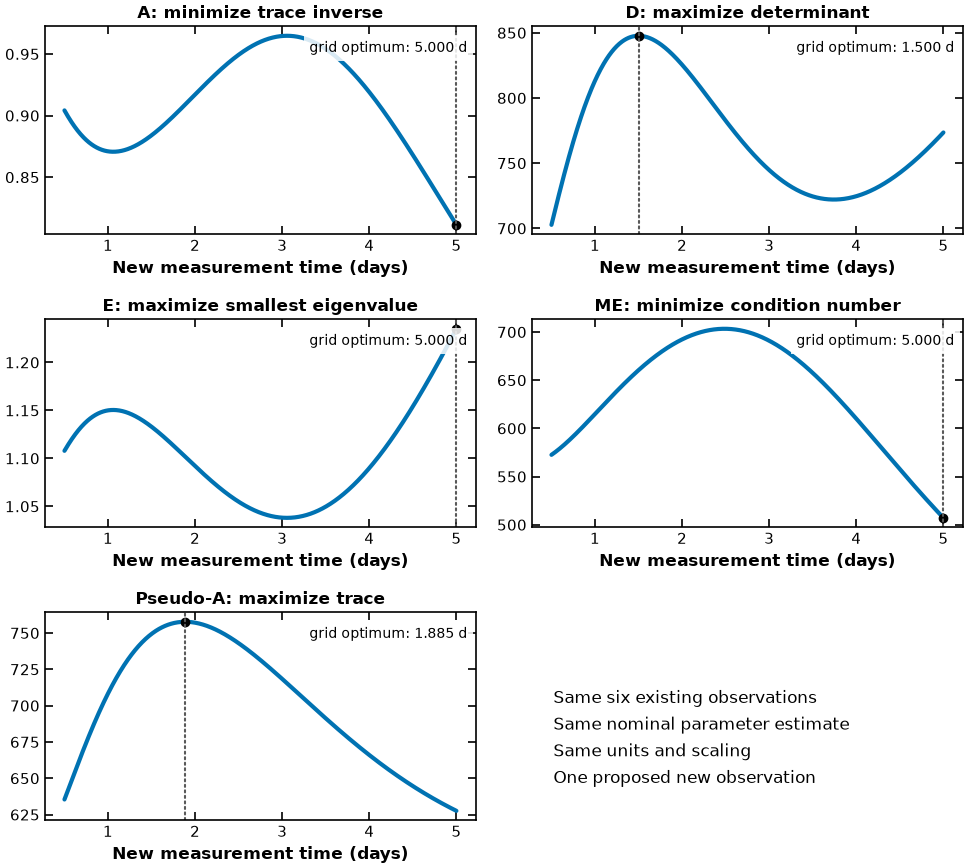

In [34]:
def plot_all_criteria(results):
    """Use individual ordinate scales so all five objectives remain legible."""
    fig, axes = plt.subplots(3, 2, figsize=(10, 9))
    t = np.asarray(results["time"])
    for ax, (label, values) in zip(axes.flat, results["criteria"].items()):
        values = np.asarray(values)
        index = np.argmin(values) if "minimize" in label else np.argmax(values)
        ax.plot(t, values, color="#0072B2", ls="-")
        ax.plot(t[index], values[index], "ko", ms=6)
        ax.axvline(t[index], color="0.35", ls=":", lw=1.5)
        ax.set_title(label, fontsize=12)
        ax.set_xlabel("New measurement time (days)", fontsize=12)
        ax.tick_params(labelsize=11)
        ax.text(0.98, 0.93, f"grid optimum: {t[index]:.3f} d",
                transform=ax.transAxes, ha="right", va="top", fontsize=10,
                bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.85})
    axes.flat[-1].axis("off")
    axes.flat[-1].text(0.05, 0.65, "Same six existing observations\nSame nominal parameter estimate\nSame units and scaling\nOne proposed new observation",
                       transform=axes.flat[-1].transAxes, va="top", fontsize=12, linespacing=1.6)
    fig.tight_layout()
    return fig

fig = plot_all_criteria(results)
helper.save_figure(fig, "bod-design-criteria")


## Parameter scaling and Cholesky implementation

Let $\theta=D\eta$, where $D=\operatorname{diag}(s_1,\ldots,s_p)$ and $s_j>0$.
The chain rule gives $Q_\eta=Q_\theta D$ and $M_\eta=D M_\theta D$.
Thus parameter scaling changes the units in which uncertainty is compared and can
change A-, E-, ME-, and pseudo-A-optimal designs. D-optimal rankings are unchanged
by a fixed nonsingular scaling because $\det(M_\eta)=\det(D)^2\det(M_\theta)$.

Multiplying the entire information matrix by one positive constant does not change
its condition number: $\kappa_2(cM)=c\lambda_{max}/(c\lambda_{min})=\kappa_2(M)$.
`scale_constant_value` controls a common scale; `scale_nominal_param_value`
multiplies sensitivity columns by their nominal parameter values. Do not confuse
these two scaling operations.

For positive-definite $M$, a Cholesky factorization $M=LL^T$ has $L_{jj}>0$ and

$$\det M=(\det L)^2=\left(\prod_j L_{jj}\right)^2,\qquad
\log\det M=2\sum_j\log L_{jj}.$$

Pyomo.DoE introduces $L$ as variables and $M=LL^T$ as constraints for its smooth
log-determinant formulation. Eigenvalue criteria use external calculations and
derivatives. See Laky et al. (2026), Section 2 and Table 1.


## Close the loop: take the designed measurement

The design step produced a *time*, not data. Closing the loop means going back to the experiment, measuring at $t^\star$, appending the result, and re-estimating.

This is exactly where the digital experiment is needed: we evaluate the true response at $t^\star$, add one noise draw, and hand the seven-point data set back to `parmest`.

The quantity to watch is $\det\mathbf{V}_\theta$. Because the 95% confidence region is the ellipse

$$(\theta-\hat\theta)^{\mathsf{T}}\mathbf{V}_\theta^{-1}(\theta-\hat\theta)\le\chi^2_{2,0.95}=5.991,$$

its area is $\pi\,\chi^2_{2,0.95}\sqrt{\det\mathbf{V}_\theta}$. A smaller determinant is a smaller ellipse, and D-optimal design maximizes $\det\mathbf{F}$, which is the same objective seen from the other side.

In [35]:
# A separate random stream for the closed loop, so the new measurement does not
# depend on how many draws the calibration table above happened to consume.
loop_rng = np.random.default_rng(2026)

new_observation = run_digital_experiment(optimal_time, loop_rng)
print(f"Measured at t* = {optimal_time:.4f} days:  y = {new_observation:.4f}")
print(f"Noise-free truth at t*:        y = {bod_response(optimal_time, THETA_TRUE):.4f}")

augmented = pd.concat(
    [data, pd.DataFrame({"time_days": [optimal_time], "y": [new_observation]})],
    ignore_index=True,
)
augmented

Measured at t* = 1.4997 days:  y = 9.6257
Noise-free truth at t*:        y = 10.4188


,time_days,y
0,1.00000,8.300000
1,2.00000,10.300000
2,3.00000,19.000000
3,4.00000,16.000000
4,5.00000,15.600000
5,7.00000,19.800000
6,1.49974,9.625651


In [36]:
CHI2_95_2DOF = 5.991  # 95% quantile of the chi-squared distribution, 2 degrees of freedom


def ellipse_area(cov):
    """Area of the 95% confidence ellipse implied by a 2x2 covariance matrix."""
    return np.pi * CHI2_95_2DOF * np.sqrt(np.linalg.det(cov))


def summarize(label, theta, cov):
    """One row of the before/after comparison table."""
    sd = np.sqrt(np.diag(cov))
    return {
        "design": label,
        "theta_1": theta["asymptote"],
        "theta_2": theta["rate_constant"],
        "sd(theta_1)": sd[0],
        "sd(theta_2)": sd[1],
        "det(V)": np.linalg.det(cov),
        "ellipse area": ellipse_area(cov),
    }


sse_after, theta_after, covariance_after = estimate_parameters(augmented)

print("Covariance before (6 observations):\n", covariance)
print("\nCovariance after  (7 observations, measured at t*):\n", covariance_after)

closed_loop = pd.DataFrame(
    [
        summarize("before: 6 observations", theta, covariance),
        summarize(f"after: + measurement at t* = {optimal_time:.3f}", theta_after, covariance_after),
    ]
)
closed_loop

Covariance before (6 observations):
 [[ 0.95876069 -0.06652725]
 [-0.06652725  0.00634735]]

Covariance after  (7 observations, measured at t*):
 [[ 0.98389822 -0.05729307]
 [-0.05729307  0.00447954]]


,design,theta_1,theta_2,sd(theta_1),sd(theta_2),det(V),ellipse area
0,before: 6 observations,19.142575,0.531091,0.979163,0.079670,0.001660,0.766772
1,after: + measurement at t* = 1.500,19.366149,0.502868,0.991916,0.066929,0.001125,0.631260


In [37]:
determinant_drop = 1 - np.linalg.det(covariance_after) / np.linalg.det(covariance)
area_drop = 1 - ellipse_area(covariance_after) / ellipse_area(covariance)

print(f"det(V) fell by {100 * determinant_drop:.1f}%")
print(f"95% ellipse area fell by {100 * area_drop:.1f}%")

# Sanity check: one well-placed measurement should measurably shrink the region.
assert np.linalg.det(covariance_after) < np.linalg.det(covariance)

det(V) fell by 32.2%
95% ellipse area fell by 17.7%


In [38]:
sequential_results = {"before_theta": dict(theta), "after_theta": dict(theta_after),
    "before_cov": covariance.tolist(), "after_cov": covariance_after.tolist(),
    "cutoff": float(chi2.ppf(0.95, 2)), "time": float(optimal_time)}
helper.save_results("bod-sequential-ellipses", sequential_results,
    notebook="notebooks/5-dev/BOD_Parmest_DoE.ipynb",
    source_tag="handout:l8-sequential-data", solver="Ipopt/MUMPS",
    description="Actual and centered uncertainty regions before and after seventh observation")

results = sequential_results


[helper] wrote figures/results/bod-sequential-ellipses.json


[helper] wrote media/figures/bod-sequential-ellipses.png and .pdf


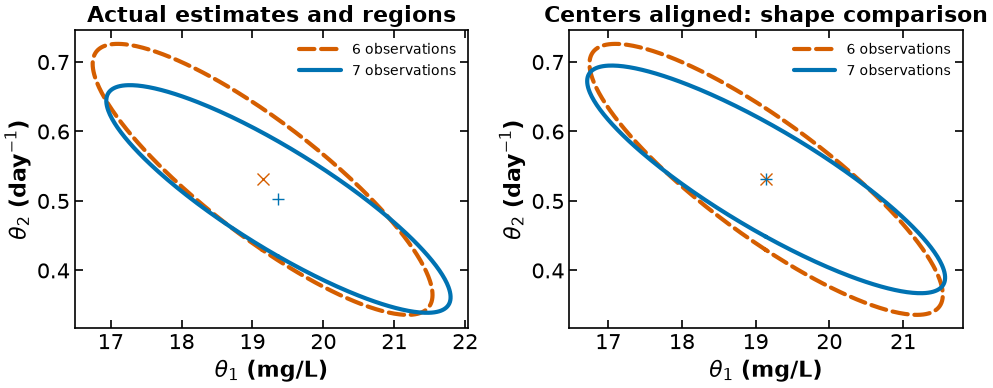

In [39]:
def plot_sequential_regions(results):
    """Separate the actual estimate shift from the change in ellipse shape."""
    fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
    angles = np.linspace(0, 2*np.pi, 361)
    circle = np.vstack([np.cos(angles), np.sin(angles)])
    before = np.array([results["before_theta"]["asymptote"], results["before_theta"]["rate_constant"]])
    after = np.array([results["after_theta"]["asymptote"], results["after_theta"]["rate_constant"]])
    for ax, centered in zip(axes, [False, True]):
        for center, cov, style, color, label in [
            (before, results["before_cov"], "--", "#D55E00", "6 observations"),
            (after, results["after_cov"], "-", "#0072B2", "7 observations")]:
            values, vectors = np.linalg.eigh(np.asarray(cov))
            shown_center = before if centered else center
            points = shown_center[:, None] + vectors @ (np.sqrt(results["cutoff"]*values)[:, None]*circle)
            ax.plot(*points, ls=style, color=color, label=label)
            ax.plot(*shown_center, marker="x" if label.startswith("6") else "+", color=color, ms=8)
        ax.set(xlabel=r"$\theta_1$ (mg/L)", ylabel=r"$\theta_2$ (day$^{-1}$)",
               title="Centers aligned: shape comparison" if centered else "Actual estimates and regions")
        ax.legend(fontsize=10)
    fig.tight_layout()
    return fig

fig = plot_sequential_regions(results)
helper.save_figure(fig, "bod-sequential-ellipses")


## A control: was the design step worth it?

A shrinking ellipse is not by itself evidence that the *design* helped. Any seventh observation adds information. The question is whether $t^\star$ adds more than a time we could have picked without optimizing.

Two controls, both inside the same 0.5--5 day window:

* $t=0.5$ days, the time the dense grid identified as the **worst** in the window; and
* $t=5$ days, the naive "measure at the end" choice.

Each control uses its own noise draw, so the three augmented data sets differ in the new point only.

In [40]:
grid_worst_time = grid[np.argmin(grid_logdet)]
print(f"Worst time on the dense grid: {grid_worst_time:.4f} days")

candidates = {
    f"optimal t* = {optimal_time:.3f}": optimal_time,
    f"worst on grid, t = {grid_worst_time:.3f}": grid_worst_time,
    "end of window, t = 5.0": 5.0,
}

# The prediction the design step makes, before any data are collected. It depends
# only on the sensitivity vector and the prior, not on the value that comes back.
predicted = []
for label, t_new in candidates.items():
    fim = updated_fim(t_new)
    predicted_cov = np.linalg.inv(fim)
    predicted.append(
        {
            "design": label,
            "predicted det(V)": np.linalg.det(predicted_cov),
            "predicted reduction": 1 - np.linalg.det(predicted_cov) / np.linalg.det(covariance),
        }
    )

pd.DataFrame(predicted)

Worst time on the dense grid: 0.5000 days


,design,predicted det(V),predicted reduction
0,optimal t* = 1.500,0.001180,0.289247
1,"worst on grid, t = 0.500",0.001423,0.142587
2,"end of window, t = 5.0",0.001293,0.221114


In [41]:
# Now take each measurement and re-estimate. The optimal row reuses the
# measurement already taken above, so this table and the one before it agree;
# each control draws its own noise from the same stream.
realized_covariance = {}
before = summarize("before: 6 observations", theta, covariance)
before["reduction in det(V)"] = 0.0
realized = [before]

for label, t_new in candidates.items():
    if t_new == optimal_time:
        y_new = new_observation
    else:
        y_new = run_digital_experiment(t_new, loop_rng)

    trial = pd.concat(
        [data, pd.DataFrame({"time_days": [t_new], "y": [y_new]})], ignore_index=True
    )
    _, theta_trial, covariance_trial = estimate_parameters(trial)
    realized_covariance[label] = covariance_trial

    row = summarize(label, theta_trial, covariance_trial)
    row["reduction in det(V)"] = 1 - row["det(V)"] / np.linalg.det(covariance)
    realized.append(row)

pd.DataFrame(realized)

,design,theta_1,theta_2,sd(theta_1),sd(theta_2),det(V),ellipse area,reduction in det(V)
0,before: 6 observations,19.142575,0.531091,0.979163,0.079670,0.001660,0.766772,0.000000
1,optimal t* = 1.500,19.366149,0.502868,0.991916,0.066929,0.001125,0.631260,0.322227
2,"worst on grid, t = 0.500",19.096537,0.536537,0.937716,0.074878,0.001437,0.713415,0.134333
3,"end of window, t = 5.0",18.441329,0.564221,0.837340,0.083908,0.001454,0.717717,0.123861


## One realization is not evidence

The table above compares three single draws. That is a weak comparison: $\mathbf{V}_\theta$ from the Gauss–Newton calculation depends on sensitivities at the refitted parameters as well as on where the measurement was placed, so a lucky draw at the worst time can beat an unlucky draw at $t^\star$.

The Fisher information prediction has no such noise in it. To check that the prediction is the right summary of what actually happens, repeat each placement over many noise draws and average the realized $\det\mathbf{V}_\theta$.

All three placements share the same standardized draws -- common random numbers -- so the comparison is between *times*, not between lucky and unlucky noise.

In [42]:
REPLICATES = 50
standardized_draws = np.random.default_rng(7).normal(0.0, 1.0, REPLICATES)

study = []
for label, t_new in candidates.items():
    determinants = []
    for z in standardized_draws:
        y_new = float(bod_response(t_new, THETA_TRUE) + MEASUREMENT_STD * z)
        trial = pd.concat(
            [data, pd.DataFrame({"time_days": [t_new], "y": [y_new]})], ignore_index=True
        )
        determinants.append(np.linalg.det(estimate_parameters(trial)[2]))

    determinants = np.array(determinants)
    study.append(
        {
            "design": label,
            "mean det(V)": determinants.mean(),
            "mean reduction": 1 - determinants.mean() / np.linalg.det(covariance),
            "predicted reduction": 1
            - np.linalg.det(np.linalg.inv(updated_fim(t_new))) / np.linalg.det(covariance),
        }
    )

pd.DataFrame(study)

,design,mean det(V),mean reduction,predicted reduction
0,optimal t* = 1.500,0.001160,0.301305,0.289247
1,"worst on grid, t = 0.500",0.001406,0.152820,0.142587
2,"end of window, t = 5.0",0.001327,0.200331,0.221114


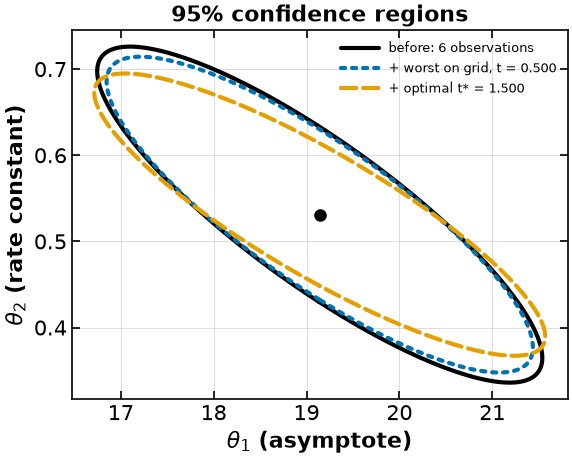

In [43]:
def confidence_ellipse(center, cov, n_points=200):
    """Points on the 95% confidence ellipse of a 2x2 covariance matrix."""
    eigenvalues, eigenvectors = np.linalg.eigh(cov)
    angle = np.linspace(0, 2 * np.pi, n_points)
    unit_circle = np.vstack([np.cos(angle), np.sin(angle)])
    radii = np.sqrt(CHI2_95_2DOF * eigenvalues)
    return (eigenvectors @ (radii[:, None] * unit_circle)).T + np.array(center)


# All three ellipses are drawn around the six-observation estimate. Each fit has
# its own center, but overlaying them there would mix a change in shape with a
# change in location; only the shape is what the design step controls.
center = [theta["asymptote"], theta["rate_constant"]]

optimal_label, worst_label = list(candidates)[0], list(candidates)[1]
ellipses = [
    (covariance, "-", "before: 6 observations"),
    (realized_covariance[worst_label], ":", f"+ {worst_label}"),
    (realized_covariance[optimal_label], "--", f"+ {optimal_label}"),
]

for cov, style, label in ellipses:
    points = confidence_ellipse(center, cov)
    plt.plot(points[:, 0], points[:, 1], linestyle=style, label=label)

plt.scatter(*center, color="black", zorder=3)
plt.xlabel(r"$\theta_1$ (asymptote)")
plt.ylabel(r"$\theta_2$ (rate constant)")
plt.title("95% confidence regions")
plt.grid(True)
plt.legend(fontsize=9)
plt.show()

The D-optimal design minimizes the determinant of the predicted covariance, hence the area of this two-parameter ellipse. It does not specifically minimize the longest axis (the E-optimal criterion). Adding positive-semidefinite information at the same nominal parameters cannot increase variance in any fixed direction; re-estimating the parameters after collecting data can also change the sensitivities and rotate the ellipse.

## Key takeaways

* Parameter estimation turns measurements into fitted parameters and an uncertainty description.
* The inverse Gauss–Newton covariance supplies local prior information for the next design.
* Experimental design asks where a new measurement adds information not already supplied by the prior.
* **A design is only a prediction.** Closing the loop -- taking the measurement and re-estimating -- is what tests it, and a digital experiment makes that possible when the real apparatus is gone.
* **Check the design against a control.** That a seventh observation shrinks the confidence region proves nothing on its own; the comparison that matters is against a measurement placed without optimizing.
* A single realization is a weak comparison, because the estimated covariance changes with the refitted parameters. Average over draws, or compare the noise-free Fisher information prediction.
* FIM designs are local: different nominal parameters, noise models, bounds, or priors can change the answer.
* Small examples permit independent checks. Use them before trusting a larger dynamic design.